In [85]:
import cv2
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt

#### https://courses.cs.washington.edu/courses/cse455/09wi/Lects/lect16.pdf


# All metrics used were either in mm or pixels

# Train data: 103 examples

In [86]:
left_imgs = glob.glob('./train_undistorted_rectified/*left.jpeg')
right_imgs = glob.glob('./train_undistorted_rectified/*right.jpeg')
print(len(left_imgs))
left_imgs.sort()
right_imgs.sort()
count = 0

depth_to_disparity = open("train_depth_to_disparity.csv", "w")
depth_to_px_width = open("train_depth_to_px_width.csv", "w")
depth_to_px_height = open("train_depth_to_px_height.csv", "w")

for left, right in zip(left_imgs, right_imgs):

    current_dist = left.split("\\")[-1].split("_")[0]

    left_rectified  = cv2.imread(left)
    right_rectified  = cv2.imread(right)
    PATTERN_SIZE = (9,6)
    criteria = (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

    res_left, corners_left = cv2.findChessboardCorners(left_rectified, PATTERN_SIZE)
    res_right, corners_right = cv2.findChessboardCorners(right_rectified, PATTERN_SIZE)

    if res_left and res_right:

        cv2.drawChessboardCorners(left_rectified, (9,6), corners_left, res_left)
        cv2.drawChessboardCorners(right_rectified, (9,6), corners_right, res_right)

        xl_1 = int(corners_left[0][0][0])
        yl_1 = int(corners_left[0][0][1])
        cv2.circle(left_rectified, (xl_1, yl_1), 4, (255, 255, 255), 2, 2)
        xl_2  = int(corners_left[1][0][0])
        yl_2 = int(corners_left[1][0][1])
        cv2.circle(left_rectified, (xl_2, yl_2), 4, (0, 255, 255), 2, 2)
        xl_3  = int(corners_left[9][0][0])
        yl_3 = int(corners_left[9][0][1])
        cv2.circle(left_rectified, (xl_3, yl_3), 4, (0, 0, 255), 2, 2)

        xr_1 = int(corners_right[0][0][0])
        yr_1 = int(corners_right[0][0][1])
        cv2.circle(right_rectified, (xr_1, yr_1), 4, (255, 255, 255), 2, 2)
        xr_2 = int(corners_right[1][0][0])
        yr_2 = int(corners_right[1][0][1])
        cv2.circle(right_rectified, (xr_2, yr_2), 4, (0, 255, 255), 2, 2)
        xr_3  = int(corners_right[9][0][0])
        yr_3 = int(corners_right[9][0][1])
        cv2.circle(right_rectified, (xr_3, yr_3), 4, (0, 0, 255), 2, 2)

        current_dist = int(current_dist)
        depth_to_disparity.write(f"{current_dist}, {xl_1-xr_1}, {yl_1-yr_1} \n")
        print(f"{current_dist}, {xl_1-xr_1}, {yl_1-yr_1} \n")
        

        px_width = xl_1-xl_3 
        px_height = yl_2-yl_1 
        
        # dist >= 2500 mm has square size of 7cm
        # dist < 2500 mm has square size of 3.5cm
        square_size =  35
        if current_dist >= 2500:
            square_size =  70
        

        px_width_mm = abs(square_size/px_width)
        px_height_mm = abs(square_size/px_height)

        depth_to_px_width.write(f"{current_dist}, {px_width_mm}\n")
        depth_to_px_height.write(f"{current_dist}, {px_height_mm} \n")


        cv2.imshow('left_rectified', left_rectified)
        cv2.imshow('right_rectified', right_rectified)
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        count+=1
print(count)
depth_to_disparity.close()
depth_to_px_width.close()
depth_to_px_height.close()

103
1100, 180, 0 

1150, 173, 0 

1200, 166, -1 

1250, 158, -1 

1300, 152, -1 

1350, 147, -1 

1400, 141, 0 

1450, 136, 0 

1500, 133, 0 

1550, 128, -1 

1600, 123, 0 

1650, 119, -1 

1700, 117, -1 

1750, 113, -1 

1800, 110, 0 

1850, 107, 0 

1900, 104, 1 

1950, 101, -1 

2000, 98, -1 

2050, 96, 0 

2100, 94, 0 

2150, 91, 0 

2200, 90, 0 

2250, 88, 0 

2300, 86, 0 

2350, 84, 0 

2400, 82, 0 

2450, 80, -1 

2500, 78, 0 

2550, 78, 0 

2600, 76, 0 

2650, 74, 0 

2700, 74, -2 

2750, 71, 1 

2800, 70, 0 

2850, 69, 0 

2900, 68, 0 

2950, 66, 0 

3000, 66, 0 

3050, 64, 0 

3100, 63, 0 

3150, 62, 0 

3200, 61, -1 

3250, 61, 0 

3300, 60, 0 

3350, 59, -1 

3400, 58, -1 

3450, 57, 0 

3500, 56, 0 

3550, 55, -1 

3600, 55, 0 

3650, 54, 0 

3700, 53, 0 

3750, 53, 0 

3800, 52, 0 

3850, 51, 1 

3900, 50, 0 

3950, 50, 0 

4000, 49, 0 

4050, 48, -1 

4100, 48, -1 

4150, 47, -1 

4200, 47, 0 

4250, 46, 0 

4300, 46, 0 

4350, 45, 1 

4400, 44, 0 

4450, 45, 0 

4500, 4

In [87]:
df_dist_vs_disparity_train = pd.read_csv("train_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_train = pd.read_csv("train_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_train = pd.read_csv("train_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

Text(0, 0.5, 'x disparity(px)')

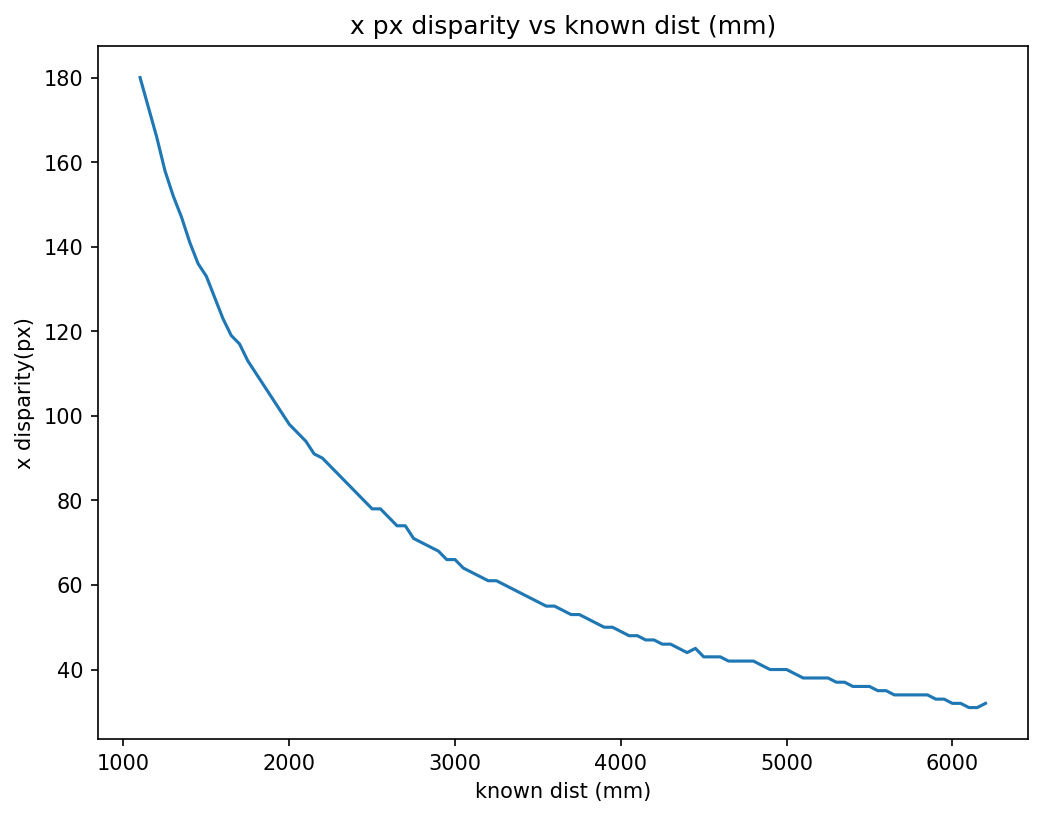

In [88]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_dist_vs_disparity_train ['dist_mm'], df_dist_vs_disparity_train ['x_disparity_px'])
plt.title('x px disparity vs known dist (mm)')
plt.xlabel("known dist (mm)")
plt.ylabel("x disparity(px)")

Text(0, 0.5, 'pixel_width_mm)')

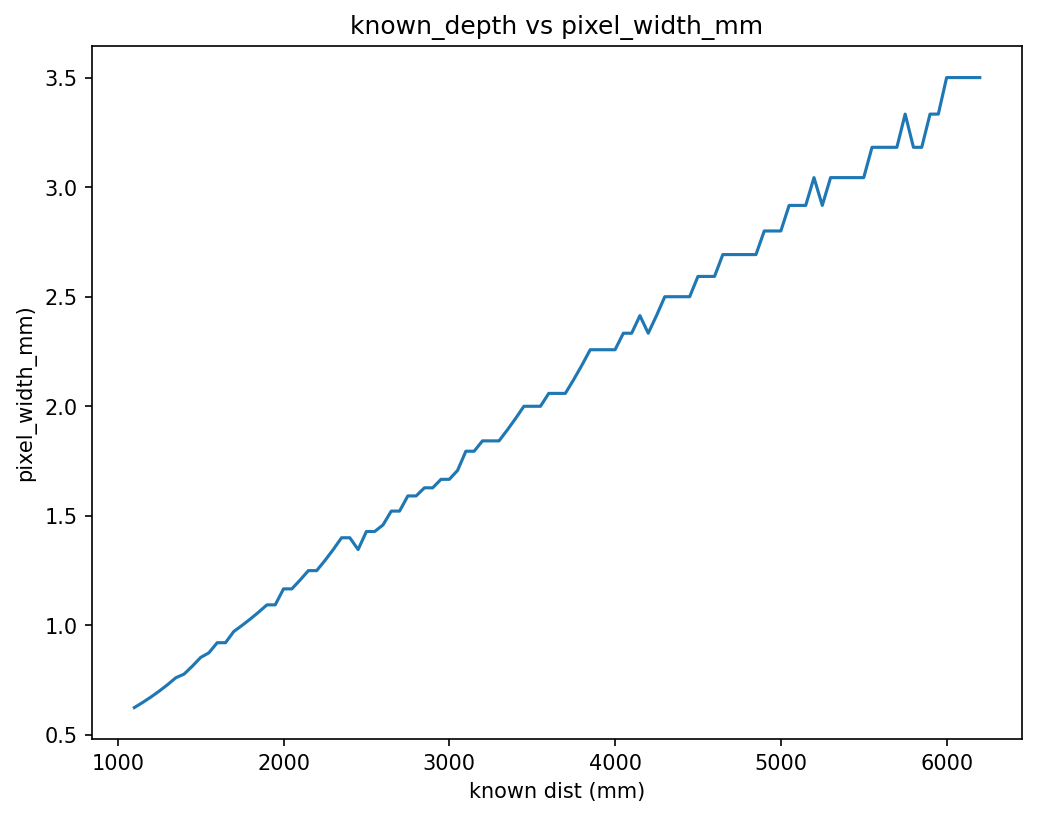

In [89]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_depth_vs_px_width_train['dist_mm'], df_depth_vs_px_width_train['pixel_width_mm'])
plt.title('known_depth vs pixel_width_mm')
plt.xlabel("known dist (mm)")
plt.ylabel("pixel_width_mm)")

Text(0, 0.5, 'pixel_height_mm)')

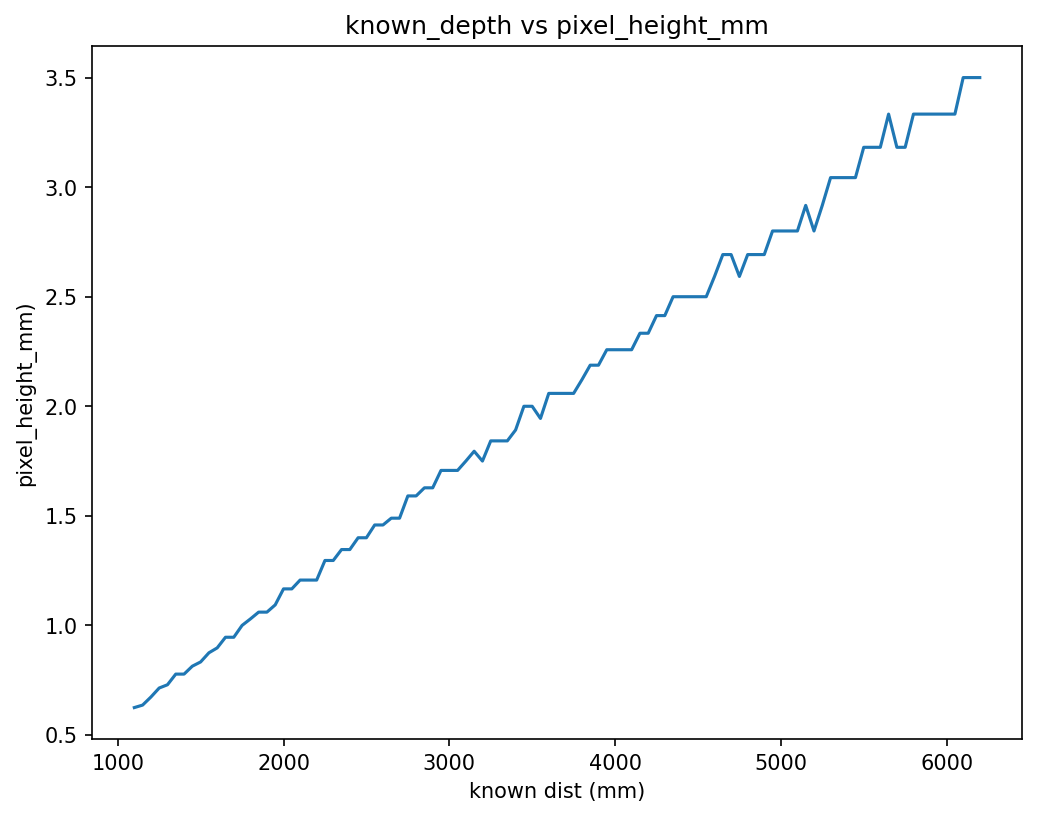

In [90]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_depth_vs_px_height_train['dist_mm'], df_depth_vs_px_height_train['pixel_height_mm'])
plt.title('known_depth vs pixel_height_mm')
plt.xlabel("known dist (mm)")
plt.ylabel("pixel_height_mm)")

# Test data: 25 examples

# Manual entry retest

In [91]:
manual_dist = pd.read_csv("test_data_manual_entry.csv", header=0)
manual_dist =manual_dist.astype(int)

left_imgs = glob.glob('./test_undistorted_rectified/*left.jpeg')
right_imgs = glob.glob('./test_undistorted_rectified/*right.jpeg')
print(len(left_imgs))
left_imgs.sort()
right_imgs.sort()
count = 0

depth_to_disparity = open("test_depth_to_disparity.csv", "w")
depth_to_px_width = open("test_depth_to_px_width.csv", "w")
depth_to_px_height = open("test_depth_to_px_height.csv", "w")

square_size =  70

for left, right in zip(left_imgs, right_imgs):
    current_dist = int(left.split("\\")[-1].split("_")[0])
    
    left_rectified  = cv2.imread(left)
    right_rectified  = cv2.imread(right)

    # NONE DET
    
    coordinates = manual_dist[manual_dist['dist'] == current_dist].iloc[0]
    xl_1 = coordinates['xl_1']
    yl_1 = coordinates['yl_1']
    cv2.circle(left_rectified, (xl_1, yl_1), 4, (255, 255, 255), 2, 2)
    xl_2  = coordinates['xl_2']
    yl_2 = coordinates['yl_2']
    cv2.circle(left_rectified, (xl_2, yl_2), 4, (0, 255, 255), 2, 2)
    xl_3  = coordinates['xl_3']
    yl_3 = coordinates['yl_3']
    cv2.circle(left_rectified, (xl_3, yl_3), 4, (0, 0, 255), 2, 2)
    xr_1 = coordinates['xr_1']
    yr_1 = coordinates['yr_1']
    cv2.circle(right_rectified, (xr_1, yr_1), 4, (255, 255, 255), 2, 2)
    xr_2 = coordinates['xr_2']
    yr_2 = coordinates['yr_2']
    cv2.circle(right_rectified, (xr_2, yr_2), 4, (0, 255, 255), 2, 2)
    xr_3  = coordinates['xr_3']
    yr_3 = coordinates['yr_3']
    cv2.circle(right_rectified, (xr_3, yr_3), 4, (0, 0, 255), 2, 2)
    count+=1

    cv2.imshow(f'{current_dist}_left', left_rectified)
    cv2.imshow(f'{current_dist}_right', right_rectified)

    cv2.waitKey(1)
    cv2.destroyAllWindows()
    
    depth_to_disparity.write(f"{current_dist}, {xl_1-xr_1}, {yl_1-yr_1} \n")
    print(f"{current_dist}, {xl_1-xr_1}, {yl_1-yr_1} \n")
    
    px_width = xl_1-xl_3 
    px_height = yl_1 - yl_2
    #print((f"{current_dist}, {px_width}, {px_height} \n"))
    px_width_mm = abs(square_size/px_width)
    px_height_mm = abs(square_size/px_height)
    #print((f"{current_dist}, {xl_1-xr_1}, {yl_1-yr_1} \n"))
    depth_to_px_width.write(f"{current_dist}, {px_width_mm}\n")
    depth_to_px_height.write(f"{current_dist}, {px_height_mm} \n")


depth_to_disparity.close()
depth_to_px_width.close()
depth_to_px_height.close()
print(count)

25
1050, 170, 0 

1256, 139, 0 

1462, 119, -1 

1668, 102, 0 

1874, 90, 0 

2080, 80, 1 

2286, 71, 1 

2492, 64, 0 

2698, 58, 0 

2904, 53, 0 

3110, 49, 0 

3316, 45, 1 

3522, 42, 1 

3728, 38, 1 

3934, 35, 0 

4140, 33, 1 

4346, 30, 0 

4552, 29, 0 

4758, 27, 1 

4964, 25, 1 

5170, 23, 0 

5376, 22, 0 

5582, 21, 1 

5788, 19, 0 

5994, 18, 0 

25


In [92]:
df_dist_vs_disparity_test = pd.read_csv("test_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_test = pd.read_csv("test_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_test = pd.read_csv("test_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

Text(0, 0.5, 'x disparity(px)')

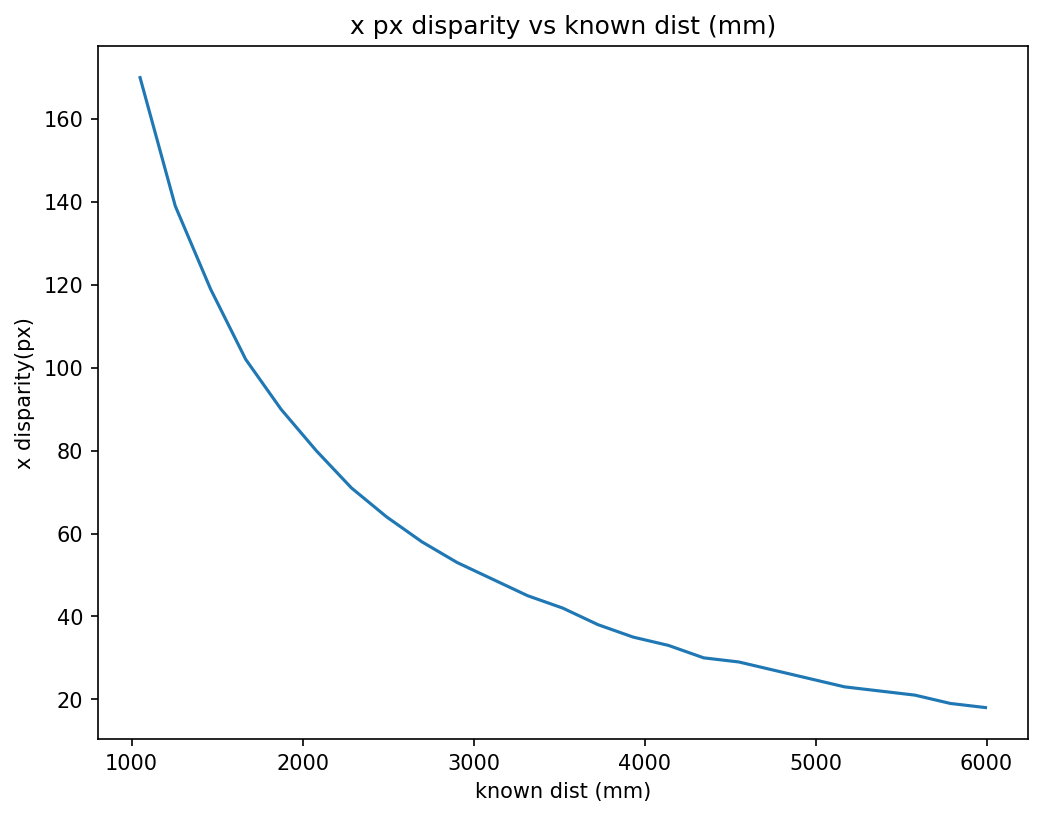

In [93]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_dist_vs_disparity_test['dist_mm'], df_dist_vs_disparity_test['x_disparity_px'])
plt.title('x px disparity vs known dist (mm)')
plt.xlabel("known dist (mm)")
plt.ylabel("x disparity(px)")

Text(0, 0.5, 'pixel_width_mm)')

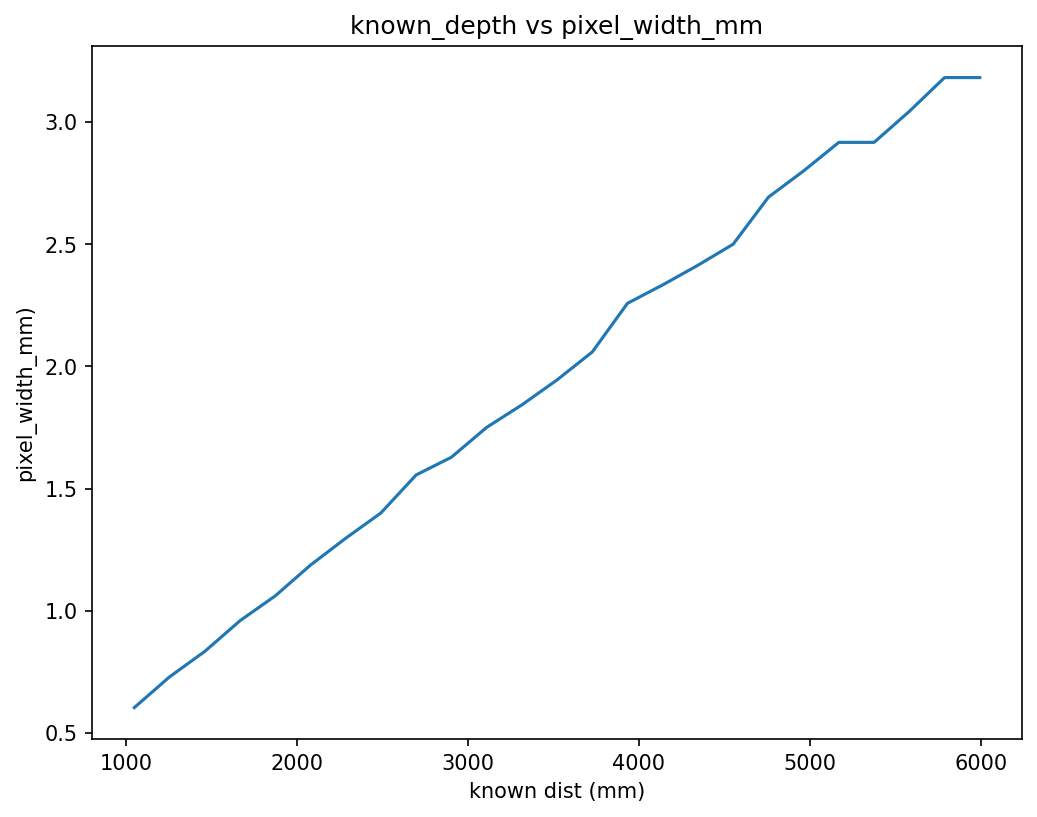

In [94]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_depth_vs_px_width_test['dist_mm'], df_depth_vs_px_width_test['pixel_width_mm'])
plt.title('known_depth vs pixel_width_mm')
plt.xlabel("known dist (mm)")
plt.ylabel("pixel_width_mm)")

Text(0, 0.5, 'pixel_height_mm)')

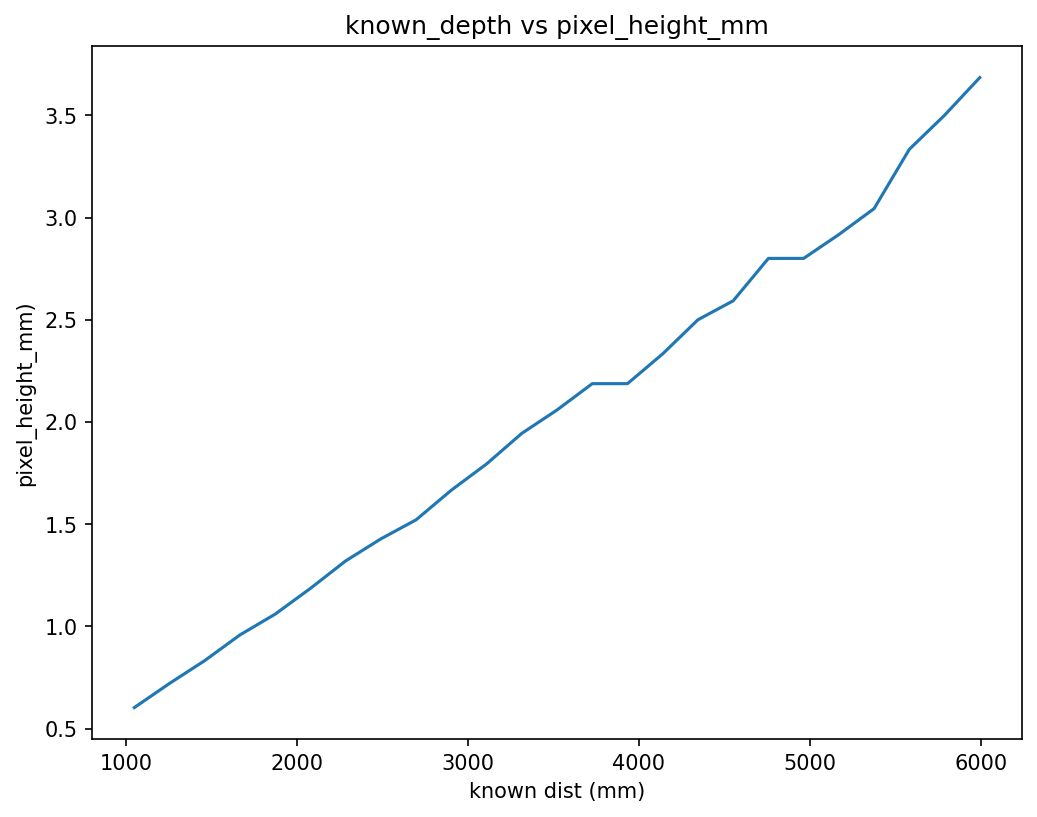

In [95]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_depth_vs_px_height_test['dist_mm'], df_depth_vs_px_height_test['pixel_height_mm'])
plt.title('known_depth vs pixel_height_mm')
plt.xlabel("known dist (mm)")
plt.ylabel("pixel_height_mm)")